In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
import joblib
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [7]:
# ==========================================
# 1. КОНФІГУРАЦІЯ ТА ДАНІ
# ==========================================
target = 'cpu'
exog_features = ['rps', 'ram']

# Завантаження (заміни на свої шляхи)
df_main = pd.read_csv("./clean_data/train_data_2.csv") 
df_ext = pd.read_csv("./clean_data/training_data.csv") 

# Емуляція для тесту (видали перед запуском)
# df_main = pd.DataFrame(np.random.rand(600, 3), columns=[target] + exog_features)
# df_ext = pd.DataFrame(np.random.rand(150, 3), columns=[target] + exog_features)

# Масштабування (для SARIMAX важливо, щоб зовнішні змінні були в одному масштабі)
scaler_exog = StandardScaler()
exog_train = scaler_exog.fit_transform(df_main[exog_features])
exog_test = scaler_exog.transform(df_ext[exog_features])

y_train = df_main[target].values
y_test = df_ext[target].values

In [3]:
# ==========================================
# 2. AUTO-ARIMA: ПОВНИЙ ГРІД-СЕРЧ (MAXIMUM)
# ==========================================
print(f"🚀 Шукаємо найкращу математичну модель для {target.upper()}...")

# Використовуємо AIC (Akaike Information Criterion) для вибору
model_search = pm.auto_arima(
    y_train, 
    X=exog_train,        # Зовнішні фактори (RPS, RAM)
    start_p=1, start_q=1,
    max_p=3, max_q=3,    # Глибина авторегресії
    m=12,                # Припускаємо цикл (наприклад, 12 кроків)
    seasonal=True,       # Шукаємо сезонність
    stepwise=False,      # ПОВНИЙ перебір (не пропускаємо жодної комбінації)
    n_jobs=-1,           # Використовуємо всі ядра процесора
    trace=True
)

print(f"\n🏆 Знайдено найкращий порядок: {model_search.order} x {model_search.seasonal_order}")

🚀 Шукаємо найкращу математичну модель для CPU...
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-11961.972, Time=0.21 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-11998.555, Time=1.00 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-13387.743, Time=1.34 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=-11992.079, Time=3.09 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=5.41 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=-13488.584, Time=5.87 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-13500.174, Time=7.13 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=-12019.661, Time=8.22 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-13501.436, Time=9.20 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=-13503.585, Time=3.16 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=-12008.383, Time=13.05 sec
 ARIMA(0,1,2)(1,0,1)[12] intercept   : AIC=-13416.320, Time=4.02 sec
 ARIMA(0,1,2)(0,0,1)[12] intercept   : AIC=-13494.193, Time=10.11 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=-13395.575, Time

In [9]:
# ==========================================
# 3. ТРЕНУВАННЯ ТА ТЕСТ НА LOCUST
# ==========================================
# Створюємо фінальну модель SARIMAX
final_sarimax = SARIMAX(
    y_train,
    exog=exog_train,
    order=model_search.order,
    seasonal_order=model_search.seasonal_order
).fit(disp=False)

# Робимо прогноз на базі RPS/RAM з Locust-сценарію
forecast_res = final_sarimax.get_forecast(steps=len(y_test), exog=exog_test)
y_pred = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

/home/bohdan/projects/personal/diploma_git/diploma/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



📊 Результат на Locust-тесті (CPU Prediction):
 - MSE: 0.00202
 - MAE: 0.03585


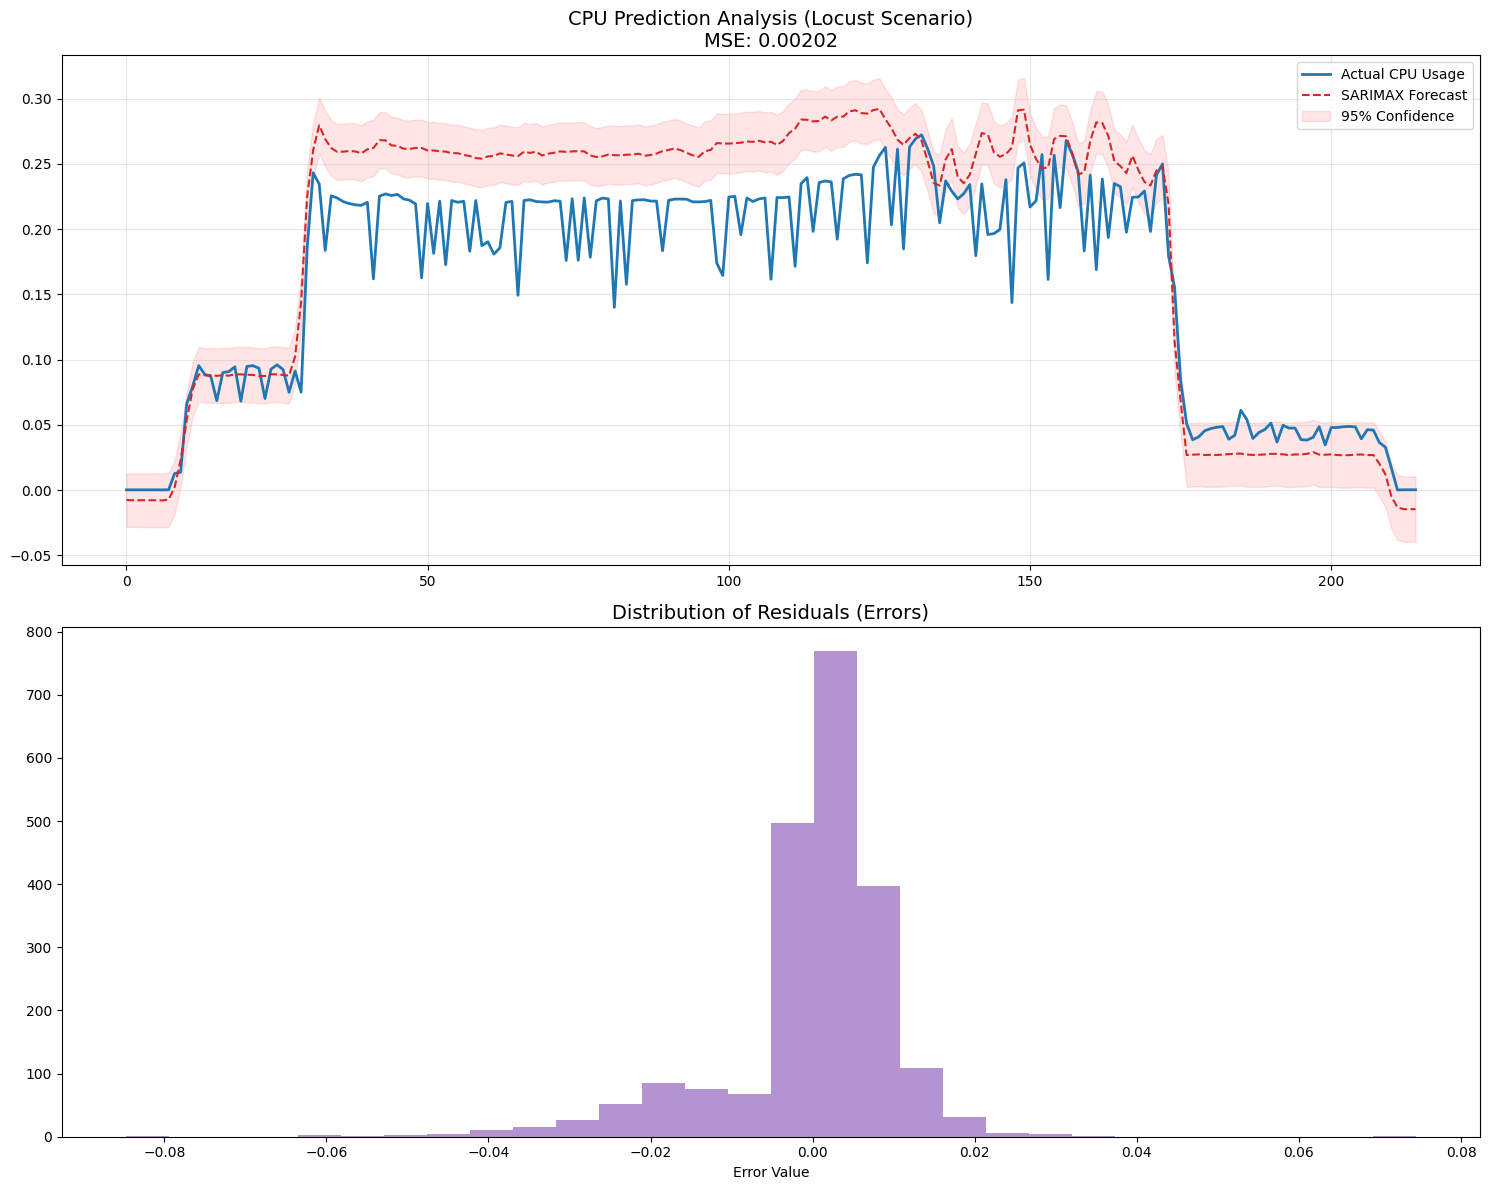

In [10]:
# ==========================================
# 4. АНАЛІЗ ТА ГРАФІКИ
# ==========================================
mse = mean_squared_error(y_test, y_pred)
print(f"\n📊 Результат на Locust-тесті (CPU Prediction):")
print(f" - MSE: {mse:.5f}")
print(f" - MAE: {mean_absolute_error(y_test, y_pred):.5f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Графік 1: Реальний CPU vs Прогноз
ax1.plot(y_test, label='Actual CPU Usage', color='#1f77b4', linewidth=2)
ax1.plot(y_pred, label='SARIMAX Forecast', color='#d62728', linestyle='--')
ax1.fill_between(range(len(y_test)), conf_int[:, 0], conf_int[:, 1], color='red', alpha=0.1, label='95% Confidence')
ax1.set_title(f'CPU Prediction Analysis (Locust Scenario)\nMSE: {mse:.5f}', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Графік 2: Діагностика залишків (Residuals)
residuals = final_sarimax.resid
ax2.hist(residuals, bins=30, color='#9467bd', alpha=0.7)
ax2.set_title('Distribution of Residuals (Errors)', fontsize=14)
ax2.set_xlabel('Error Value')

plt.tight_layout()
plt.show()

# Збереження для диплома
# joblib.dump(final_sarimax, "sarimax_cpu_model.joblib")